# 03 Gaze Shift Heatmaps

This notebook runs the grating gaze grid and visualizes where inferred PO changes are largest. Heat maps are useful because gaze shifts have both magnitude and direction. The debug grid is coarse; the full config uses 0.1 degree steps from 0 to 10 degrees.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.utils import load_config, rng_from_config
from src.sampling import sample_population
from src.simulation import perfect_mapping_config, run_grating_shift_grid
from src.plotting import set_plot_style, heatmap_from_table
from src.stimuli import make_moving_grating_stimuli

set_plot_style()
fig_dir = ROOT / 'results/figures'
fig_dir.mkdir(parents=True, exist_ok=True)

cfg = load_config(ROOT / 'configs/default.yaml', debug=True)
rng = rng_from_config(cfg)
pop = sample_population(cfg, rng)
result = run_grating_shift_grid(pop, cfg, rng)
summary = result['summary']
display(summary.head())


,gaze_az_deg,gaze_el_deg,median_abs_delta_po_deg,p90_abs_delta_po_deg,fraction_abs_delta_po_gt_threshold,median_signed_delta_po_deg,median_circular_variance_change,median_tuning_strength_change,median_abs_tuning_strength_change
0,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
1,1.0,0.0,1.587615,13.187187,0.13125,0.352869,0.000489,-0.000489,0.021290
2,2.0,0.0,3.922636,24.255427,0.26875,0.386679,-0.004180,0.004180,0.029516
3,3.0,0.0,5.065766,26.877367,0.36250,0.720295,-0.007680,0.007680,0.039022
4,4.0,0.0,7.113108,35.595106,0.39375,0.638707,-0.003045,0.003045,0.047228


## Primary Heat Maps

The first heat map asks whether the inferred PO moves. The next two ask whether the tuning curve changes without necessarily rotating: circular variance can rise, and vector strength can fall.

In [2]:
heatmap_from_table(summary, 'median_abs_delta_po_deg', fig_dir / 'notebook03_median_abs_delta_po.png', title='Median |ΔPO|')
heatmap_from_table(summary, 'median_circular_variance_change', fig_dir / 'notebook03_cv_change.png', title='Median circular variance change', cmap='vlag', center=0)
heatmap_from_table(summary, 'median_tuning_strength_change', fig_dir / 'notebook03_strength_change.png', title='Median tuning strength change', cmap='vlag', center=0)
display(summary.tail())

,gaze_az_deg,gaze_el_deg,median_abs_delta_po_deg,p90_abs_delta_po_deg,fraction_abs_delta_po_gt_threshold,median_signed_delta_po_deg,median_circular_variance_change,median_tuning_strength_change,median_abs_tuning_strength_change
31,1.0,5.0,8.172697,32.663293,0.41875,0.210930,0.009733,-0.009733,0.061320
32,2.0,5.0,8.207126,35.369451,0.45625,0.341611,0.011145,-0.011145,0.082892
33,3.0,5.0,9.619448,36.455591,0.47500,0.217554,0.013322,-0.013322,0.076030
34,4.0,5.0,9.601051,37.598139,0.48750,1.087224,0.006541,-0.006541,0.070135
35,5.0,5.0,9.486046,37.275108,0.48125,2.291346,0.006686,-0.006686,0.078289


## Neuron-Level Sensitivity at the Largest Offset

A population median can hide heterogeneity. The next plots ask whether sensitive neurons are associated with RF size or preferred SF. Narrower or higher-SF RFs are expected to be more phase-sensitive.

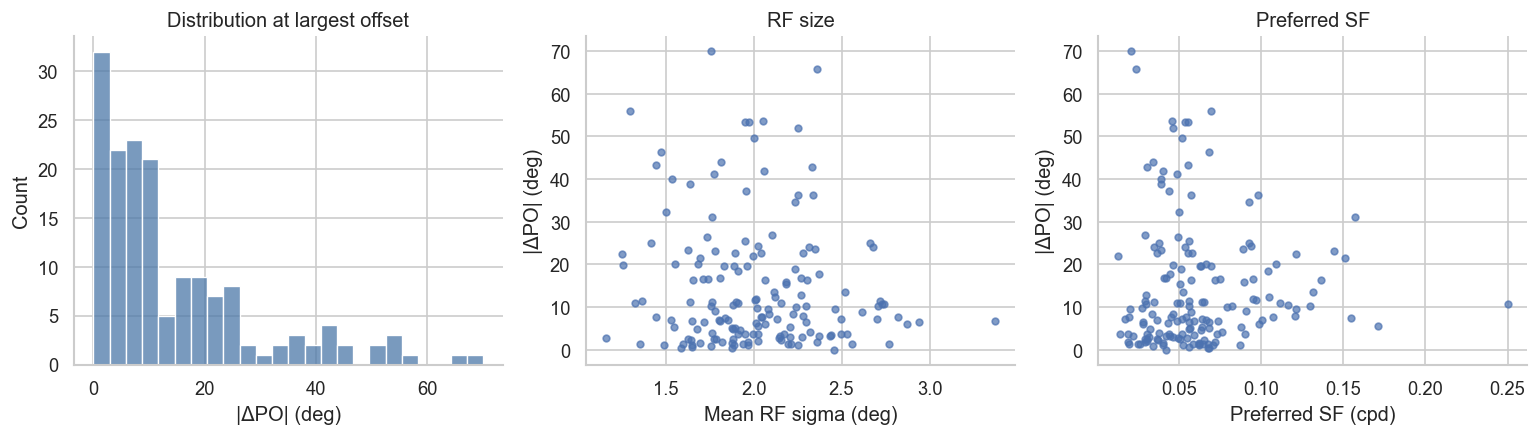

In [3]:
far = result['far_state']
changes = far['neuron_changes']
rf_size = 0.5 * (pop.sigma_x_deg.to_numpy() + pop.sigma_y_deg.to_numpy())
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
sns.histplot(changes['abs_delta_po_deg'], bins=24, ax=axes[0], color='#4C78A8')
axes[0].set_xlabel('|ΔPO| (deg)'); axes[0].set_title('Distribution at largest offset')
axes[1].scatter(rf_size, changes['abs_delta_po_deg'], s=16, alpha=0.7)
axes[1].set_xlabel('Mean RF sigma (deg)'); axes[1].set_ylabel('|ΔPO| (deg)'); axes[1].set_title('RF size')
axes[2].scatter(pop.f0_cpd, changes['abs_delta_po_deg'], s=16, alpha=0.7)
axes[2].set_xlabel('Preferred SF (cpd)'); axes[2].set_ylabel('|ΔPO| (deg)'); axes[2].set_title('Preferred SF')
plt.tight_layout()
plt.savefig(fig_dir / 'notebook03_neuron_sensitivity_summary.png', bbox_inches='tight')

## Example Tuning Curves

These examples are selected by low, median, and high `|ΔPO|`. Some neurons rotate their estimated PO; others mainly flatten or reshape their tuning curve.

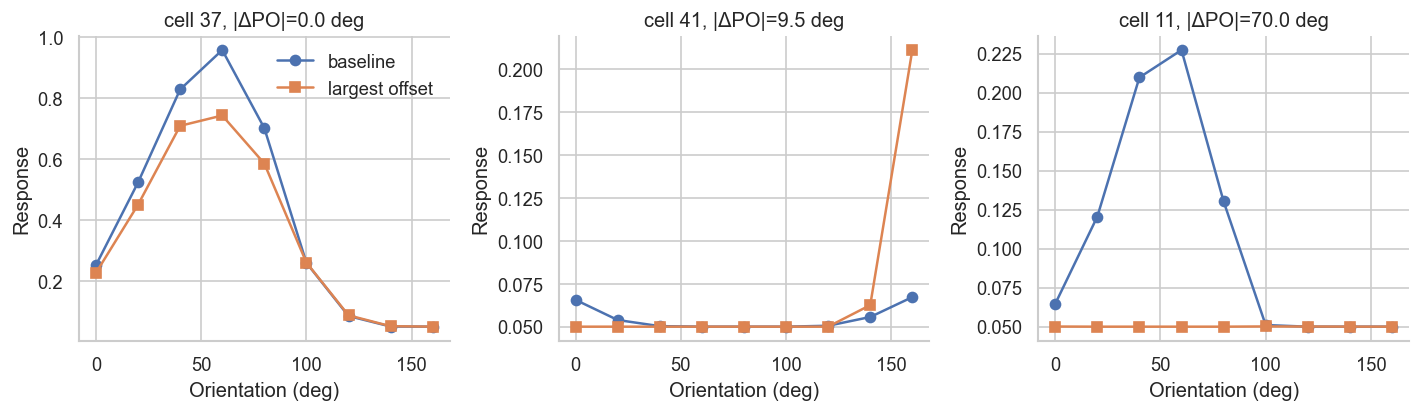

In [4]:
selected = np.argsort(changes['abs_delta_po_deg'])
example_ids = [int(selected[0]), int(selected[len(selected)//2]), int(selected[-1])]
base_tuning = result['baseline_tuning']['tuning_curve']
shift_tuning = far['tuning']['tuning_curve']
oris = result['stimuli']['orientations_deg']
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=False)
for ax, neuron in zip(axes, example_ids):
    ax.plot(oris, base_tuning[neuron], 'o-', label='baseline')
    ax.plot(oris, shift_tuning[neuron], 's-', label='largest offset')
    ax.set_title(f"cell {neuron}, |ΔPO|={changes['abs_delta_po_deg'][neuron]:.1f} deg")
    ax.set_xlabel('Orientation (deg)'); ax.set_ylabel('Response')
axes[0].legend(frameon=False)
plt.tight_layout()
plt.savefig(fig_dir / 'notebook03_example_tuning_curves.png', bbox_inches='tight')

## Moving-Grating Heat Maps

The same gaze grid can be run with moving gratings. Here the comparison is between a sparse one-time-point sample and dense temporal averaging over one full drift cycle. If the model is behaving as intended, the one-time-point condition can show apparent `ΔPO`, while dense temporal sampling and the energy model should strongly reduce it.


,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
energy model,36.0,0.000,0.000,0.0,0.000,0.000,0.000,0.000
"simple, 1 time",36.0,10.602,3.854,0.0,8.933,11.641,13.532,15.772
"simple, 24 times",36.0,0.013,0.003,0.0,0.013,0.014,0.015,0.017


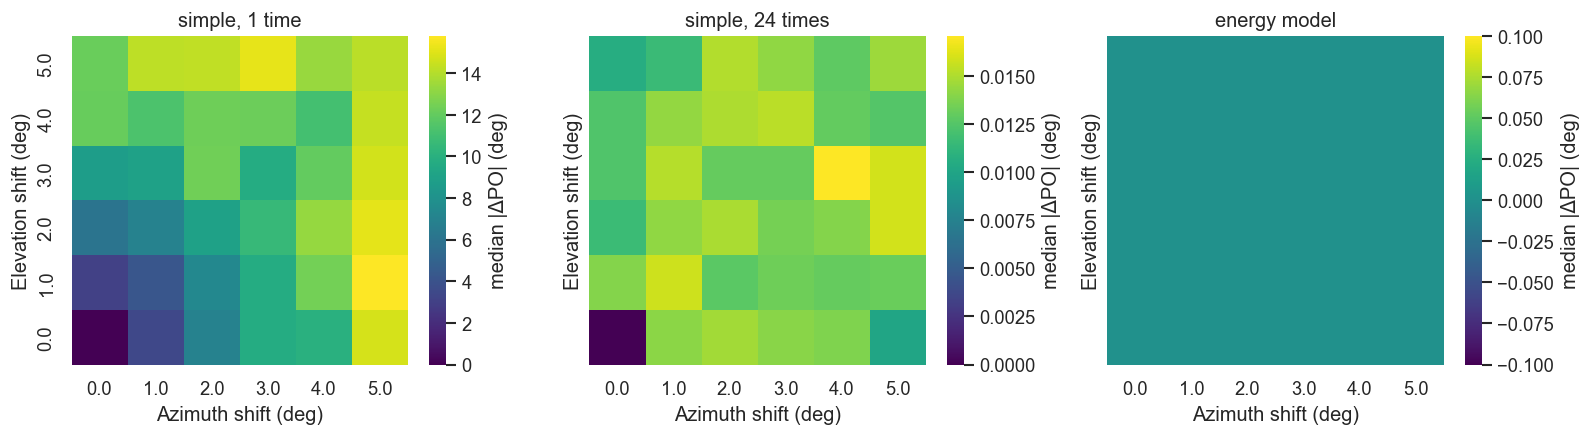

In [5]:
moving_rows = []
for label, model, time_samples in [
    ('simple, 1 time', 'simple', 1),
    ('simple, 24 times', 'simple', 24),
    ('energy model', 'energy', 1),
]:
    moving_cfg = deepcopy(cfg)
    tf_hz = float(moving_cfg['stimuli']['moving_gratings']['temporal_frequency_hz'])
    moving_cfg['stimuli']['moving_gratings']['time_samples'] = int(time_samples)
    moving_cfg['stimuli']['moving_gratings']['duration_s'] = 1.0 / tf_hz
    moving_cfg['stimuli']['moving_gratings']['phases_deg'] = [0.0]
    moving_stim = make_moving_grating_stimuli(moving_cfg)
    moving = run_grating_shift_grid(
        pop,
        moving_cfg,
        rng_from_config(moving_cfg, offset=300 + time_samples),
        mapping_config=perfect_mapping_config(),
        noise_config={'model': 'none', 'repeats': 1},
        response_model=model,
        stimuli=moving_stim,
    )['summary']
    moving['condition'] = label
    moving_rows.append(moving)

moving_summary = pd.concat(moving_rows, ignore_index=True)
display(moving_summary.groupby('condition')['median_abs_delta_po_deg'].describe().round(3))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharey=True)
for ax, (label, table) in zip(axes, moving_summary.groupby('condition', sort=False)):
    pivot = table.pivot(index='gaze_el_deg', columns='gaze_az_deg', values='median_abs_delta_po_deg').sort_index(ascending=False)
    sns.heatmap(pivot, ax=ax, cmap='viridis', cbar_kws={'label': 'median |ΔPO| (deg)'})
    ax.set_title(label)
    ax.set_xlabel('Azimuth shift (deg)')
    ax.set_ylabel('Elevation shift (deg)')
plt.tight_layout()
plt.savefig(fig_dir / 'notebook03_moving_grating_delta_po_heatmaps.png', bbox_inches='tight')

These moving-grating maps are a direct sanity check on the mechanism. A translated full-field moving grating should not become a rotated grating. Any deterministic `ΔPO` that disappears with dense temporal averaging is phase-sampling behavior, not true orientation retuning.

## Takeaway

Interpret grating heat maps together with phase-sanity checks. Large ΔPO in this simple-cell grating pipeline is not evidence that gaze physically rotates full-field gratings; it shows where phase-sensitive or noisy estimation can make the inferred PO unstable.